# 1.4 Ableitungen & Gradienten — Lösung

Begleit-Notebook zu **Lektion 1.4**: numerische Ableitungen, Gradienten, Gradient Checking und ein Mini-Autograd mit der Kettenregel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
rng = np.random.default_rng(42)

## 1. Numerische Ableitung

In [2]:
def ableitung(f, x, h=1e-5):
    # zentrale Differenz
    return (f(x + h) - f(x - h)) / (2 * h)

f = lambda x: 0.15 * x**3 - 0.9 * x + 1
df = lambda x: 0.45 * x**2 - 0.9          # analytisch
for x in [-2.0, 0.0, 1.2, 3.0]:
    print(f"x = {x:5.1f}: analytisch {df(x):8.5f}  numerisch {ableitung(f, x):8.5f}")

x =  -2.0: analytisch  0.90000  numerisch  0.90000
x =   0.0: analytisch -0.90000  numerisch -0.90000
x =   1.2: analytisch -0.25200  numerisch -0.25200
x =   3.0: analytisch  3.15000  numerisch  3.15000


**Aufgabe 1.2:** Wie hängt der Fehler der Vorwärts- bzw. zentralen Differenz von `h` ab? Zeichne beide Fehler log-log.
Warum wird der Fehler für sehr kleine `h` wieder größer? (Stichwort: Rundungsfehler bei Gleitkommazahlen)

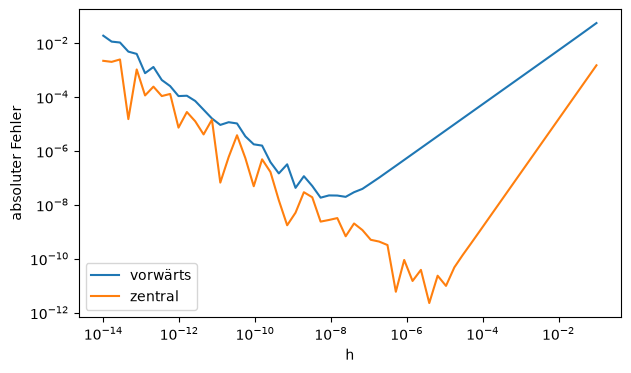

In [3]:
hs = np.logspace(-14, -1, 60)
x0 = 1.2
# Fehler der Vorwärtsdifferenz (f(x+h)-f(x))/h und der zentralen Differenz gegenüber df(x0)
fehler_vor = np.abs((f(x0 + hs) - f(x0)) / hs - df(x0))
fehler_zentral = np.abs((f(x0 + hs) - f(x0 - hs)) / (2 * hs) - df(x0))
plt.loglog(hs, fehler_vor, label="vorwärts"); plt.loglog(hs, fehler_zentral, label="zentral")
plt.xlabel("h"); plt.ylabel("absoluter Fehler"); plt.legend(); plt.show()

## 2. Gradienten

**Aufgabe 2.1:** Implementiere einen numerischen Gradienten für Funktionen $f: \mathbb{R}^d \to \mathbb{R}$ (eine Komponente nach der anderen)
und vergleiche ihn mit dem analytischen Gradienten von $f(x, y) = x^2 + 3xy + y^3$.

In [4]:
def num_gradient(f, v, h=1e-5):
    g = np.zeros_like(v, dtype=float)
    for i in range(len(v)):
        # Einheitsvektor e_i bauen, zentrale Differenz in Richtung e_i
        e = np.zeros_like(v, dtype=float)
        e[i] = h
        g[i] = (f(v + e) - f(v - e)) / (2 * h)
    return g

f2 = lambda v: v[0] ** 2 + 3 * v[0] * v[1] + v[1] ** 3
# analytischer Gradient (siehe Lektion)
grad_f2 = lambda v: np.array([2 * v[0] + 3 * v[1], 3 * v[0] + 3 * v[1] ** 2])
p = np.array([1.0, -2.0])
print(num_gradient(f2, p), grad_f2(p))

[-4. 15.] [-4. 15.]


### Gradientenfeld zeichnen

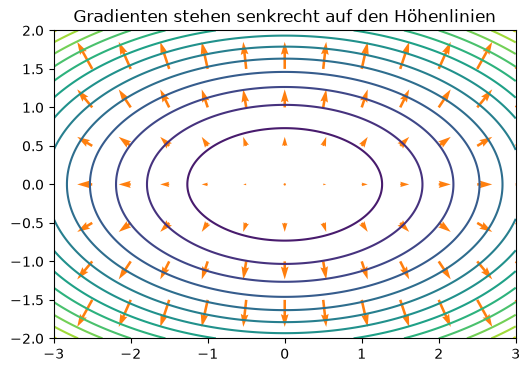

In [5]:
g = lambda v: 0.5 * v[0] ** 2 + 1.5 * v[1] ** 2
xs, ys = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 2, 200))
plt.contour(xs, ys, g([xs, ys]), levels=15)
qx, qy = np.meshgrid(np.linspace(-3, 3, 13), np.linspace(-2, 2, 9))
plt.quiver(qx, qy, qx, 3 * qy, color="tab:orange")    # ∇g = (x, 3y)
plt.gca().set_aspect("equal"); plt.title("Gradienten stehen senkrecht auf den Höhenlinien"); plt.show()

## 3. Gradient Checking für den MSE

Das lineare Modell $\hat y = Xw + b$ mit $L = \frac1n \sum (\hat y_i - y_i)^2$ hat die Gradienten
$\nabla_w L = \frac{2}{n} X^\top(\hat y - y)$ und $\partial L/\partial b = \frac{2}{n}\sum(\hat y_i - y_i)$.

**Aufgabe 3.1:** Implementiere beide und prüfe sie mit `num_gradient`.

In [6]:
X = rng.normal(size=(30, 3))
y = rng.normal(size=30)
w = rng.normal(size=3)
b = 0.3

def mse(w, b):
    return np.mean((X @ w + b - y) ** 2)

def mse_gradient(w, b):
    # analytische Gradienten nach w und b
    r = X @ w + b - y
    return 2 / len(y) * X.T @ r, 2 / len(y) * r.sum()

gw, gb = mse_gradient(w, b)
gw_num = num_gradient(lambda v: mse(v, b), w)
gb_num = num_gradient(lambda v: mse(w, v[0]), np.array([b]))[0]
print("max. Abweichung w:", np.max(np.abs(gw - gw_num)), "  b:", abs(gb - gb_num))

max. Abweichung w: 1.1959655488169574e-11   b: 1.3988810110276972e-13


## 4. Mini-Autograd: die Kettenregel automatisch

So funktionieren PyTorch & Co. im Kern: Jede Rechenoperation merkt sich ihre Eingaben und ihre **lokale Ableitung**.
`backward()` läuft den Graphen rückwärts und multipliziert nach der Kettenregel.

**Aufgabe 4.1:** Ergänze die lokalen Ableitungen für `*` und `**`.

In [7]:
class Wert:
    def __init__(self, data, eltern=(), name=""):
        self.data, self.grad = data, 0.0
        self._eltern = eltern
        self._rueckwaerts = lambda: None
        self.name = name

    def __add__(self, other):
        other = other if isinstance(other, Wert) else Wert(other)
        out = Wert(self.data + other.data, (self, other))
        def rueckwaerts():
            self.grad += 1.0 * out.grad        # d(a+b)/da = 1
            other.grad += 1.0 * out.grad       # d(a+b)/db = 1
        out._rueckwaerts = rueckwaerts
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Wert) else Wert(other)
        out = Wert(self.data * other.data, (self, other))
        def rueckwaerts():
            # d(a*b)/da = b, d(a*b)/db = a  — jeweils mal out.grad (Kettenregel)
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._rueckwaerts = rueckwaerts
        return out

    def __pow__(self, k):
        out = Wert(self.data ** k, (self,))
        def rueckwaerts():
            # d(a^k)/da = k * a^(k-1)
            self.grad += k * self.data ** (k - 1) * out.grad
        out._rueckwaerts = rueckwaerts
        return out

    __radd__ = __add__
    __rmul__ = __mul__

    def backward(self):
        # Knoten in topologischer Reihenfolge sammeln, dann rückwärts abarbeiten
        reihenfolge, besucht = [], set()
        def besuche(v):
            if v not in besucht:
                besucht.add(v)
                for e in v._eltern:
                    besuche(e)
                reihenfolge.append(v)
        besuche(self)
        self.grad = 1.0
        for v in reversed(reihenfolge):
            v._rueckwaerts()


# Beispiel aus der Lektion: f(x) = (3x + 1)^2 bei x = 2  →  df/dx = 42
x = Wert(2.0)
f = (3 * x + 1) ** 2
f.backward()
print("f =", f.data, " df/dx =", x.grad)

f = 49.0  df/dx = 42.0


**Aufgabe 4.2:** Nutze dein Autograd für ein lineares Modell mit einem Beispiel: $L = (w x + b - y)^2$ mit $x=1.5$, $y=4$, $w=0.5$, $b=1$.
Vergleiche `w.grad` und `b.grad` mit den Formeln $2(\hat y - y)x$ und $2(\hat y - y)$.

In [8]:
# Werte anlegen, Verlust berechnen, backward() aufrufen
w, b = Wert(0.5), Wert(1.0)
x_, y_ = 1.5, 4.0
L = (w * x_ + b + (-y_)) ** 2
L.backward()
y_hat = 0.5 * 1.5 + 1.0
print("Autograd:", w.grad, b.grad)
print("Formel:  ", 2 * (y_hat - y_) * x_, 2 * (y_hat - y_))

Autograd: -6.75 -4.5
Formel:   -6.75 -4.5
